In [1]:
import torch
import torch.nn as nn

# Simulation parameters
I_0 = 10000000.0  # Assume uniform blank scan
n_dimensions = torch.tensor(30)
m_dimensions = torch.tensor(40)
k_dimensions = torch.tensor(5)

# Generate nonnegative matrices
data_A = torch.rand((n_dimensions, k_dimensions))
data_B = torch.rand((k_dimensions, m_dimensions))

# Normalize A
data_A = data_A / torch.sum(data_A, dim=1, keepdim=True)

# Compute matrix product
data_Z = torch.matmul(data_A, data_B)

# Generate Poisson data
rate = I_0 * torch.exp(-data_Z)
data_I = torch.distributions.Poisson(rate).sample()

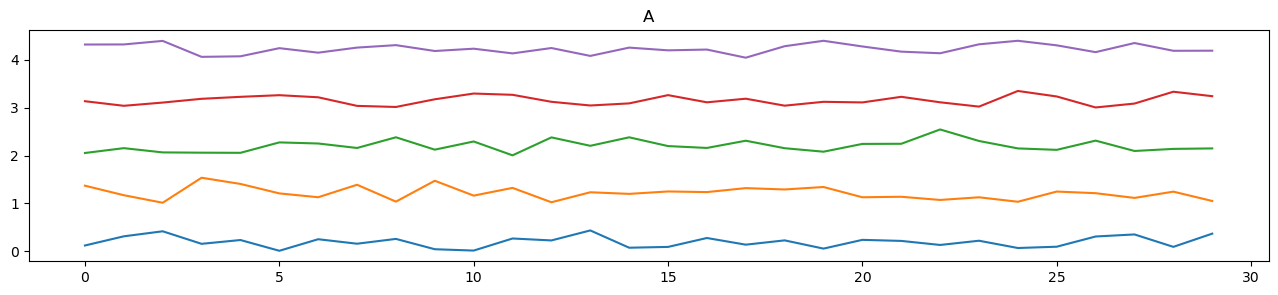

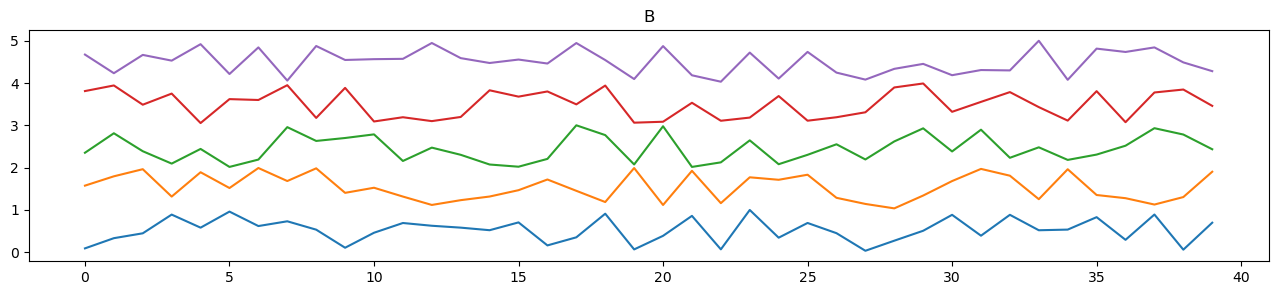

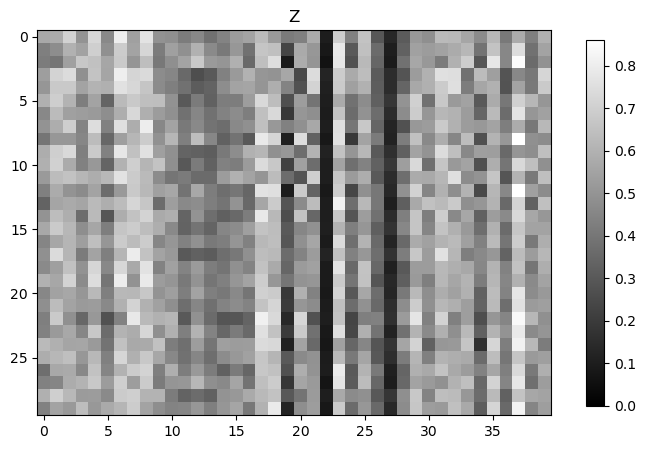

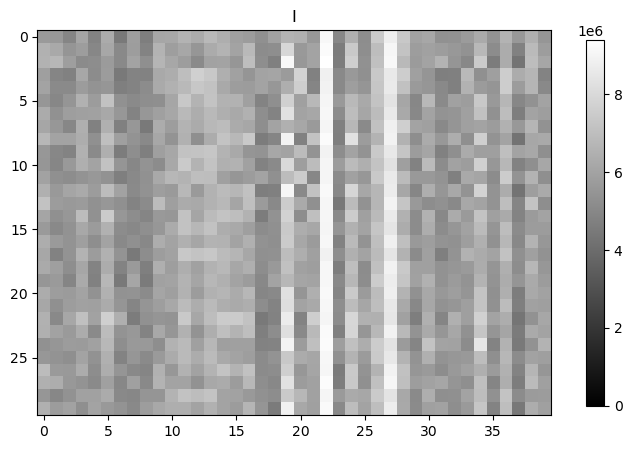

In [2]:
import matplotlib.pyplot as plt

def plot_matrix(ax, data, title, vmin=None, vmax=None):
    out = ax.imshow(data, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    return out

def plot_matrix_rows(ax, data, title):
    for i, row in enumerate(data):
        ax.plot(i + row)
    ax.set_title(title)

fig, ax = plt.subplots(figsize=(16, 3))
plot_matrix_rows(ax, data_A.T, "A")
fig, ax = plt.subplots(figsize=(16, 3))
plot_matrix_rows(ax, data_B, "B")

fig, ax = plt.subplots(figsize=(9, 5))
im = plot_matrix(ax, data_Z, "Z", vmin=0)
plt.colorbar(im, ax=ax, shrink=0.95)
fig, ax = plt.subplots(figsize=(9, 5))
im = plot_matrix(ax, data_I, "I", vmin=0)
plt.colorbar(im, ax=ax, shrink=0.95)

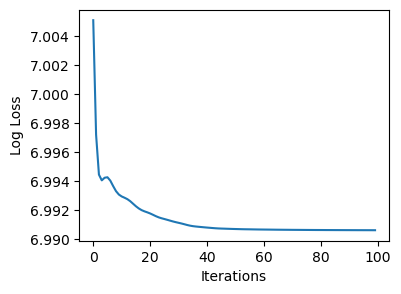

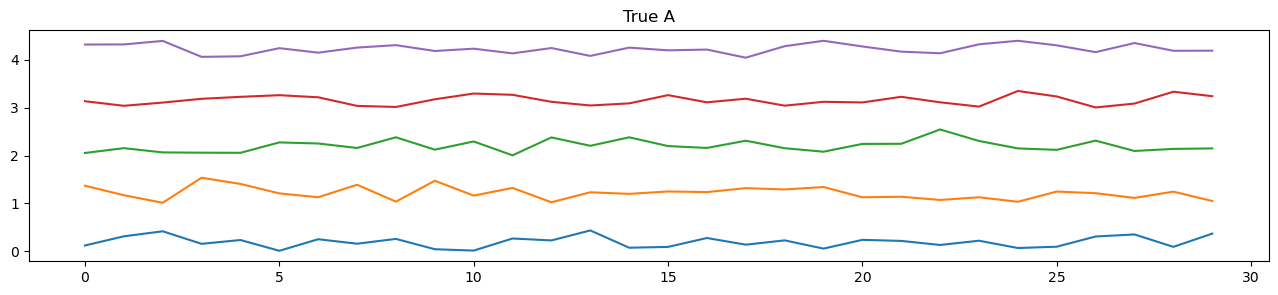

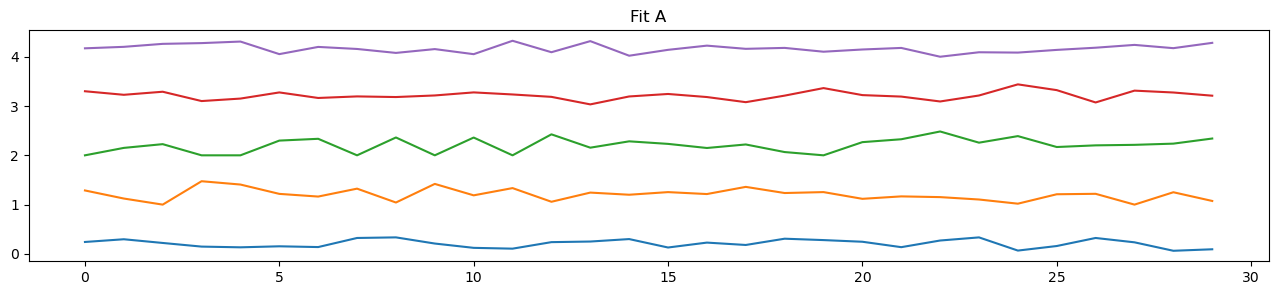

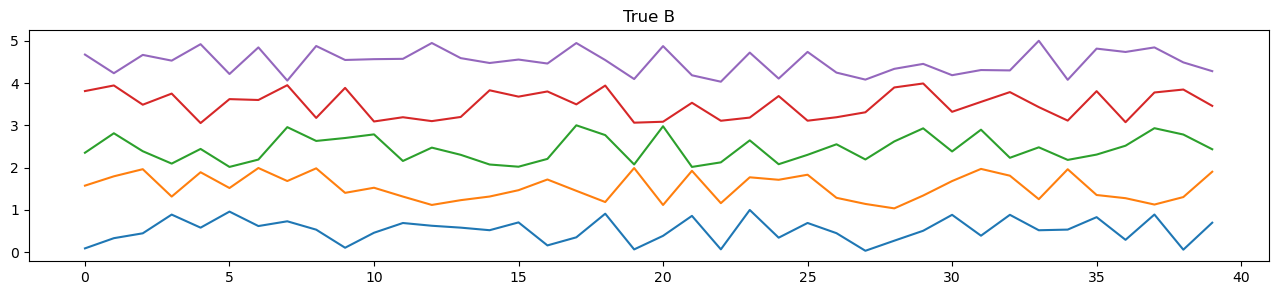

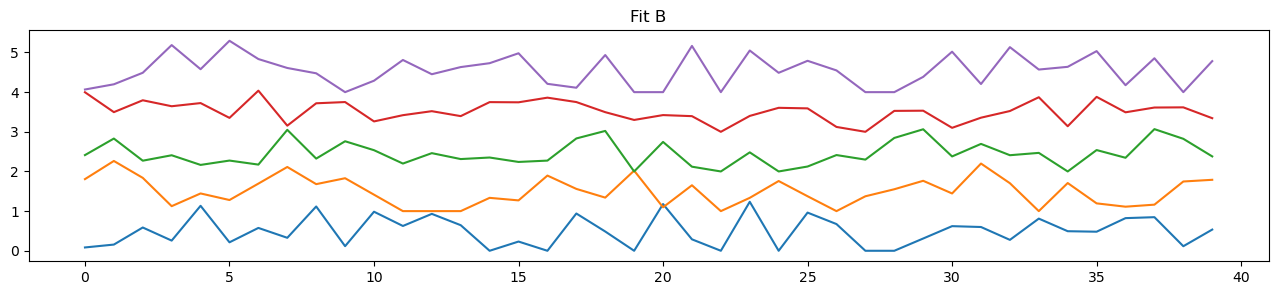

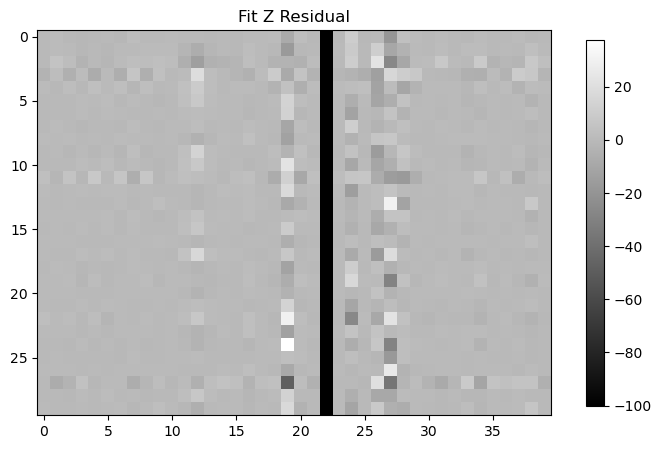

In [ ]:
import torch.nn.functional as F

from torch.nn.utils import parametrize

# Define parametrization functions
class Nonnegative(nn.Module):
    def forward(self, eta):
        return F.relu(eta)

    def right_inverse(self, x):
        return x

class NonnegativeRowSums(nn.Module):
    def forward(self, eta):
        eta = F.relu(eta)
        return eta / torch.sum(eta, dim=1, keepdim=True)

    def right_inverse(self, x):
        return x

# Define class for constrained optimization
class NonnegativeAttenuationLoss(nn.Module):
    def __init__(self, shape):
        super().__init__()
        n_dimensions, k_dimensions, m_dimensions = shape

        # Initialize matrices randomly
        A = torch.rand((n_dimensions, k_dimensions))
        B = torch.rand((k_dimensions, m_dimensions))

        # Make matrices parameters so they are optimized by Pytorch
        self.A = nn.Parameter(A)
        self.B = nn.Parameter(B)

        # Add nonnegative parametrization
        parametrize.register_parametrization(self, "A", NonnegativeRowSums())
        parametrize.register_parametrization(self, "B", Nonnegative())

    def forward(self, x):
        # Compute negative log likelihood
        T = x / I_0
        Z = torch.matmul(self.A, self.B)
        return torch.sum(torch.exp(-Z) + T * Z)

# Optimization function
# TODO Use dataloader (returns rows of Z) to fit subset of pixels
def train_model(model, data, n_iterations=100, lr=0.1):
    # We initialize an optimizer for the model parameters
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # We take n_iterations steps of gradient descent
    losses = []
    for _ in range(n_iterations):
        optimizer.zero_grad()
        loss = model(data)
        loss.backward()
        optimizer.step()
        losses.append(torch.log(loss).detach())

    plt.figure(figsize=(4, 3))
    plt.plot(losses)
    plt.xlabel("Iterations")
    plt.ylabel("Log Loss")

    return losses[-1]

# Initialize the model
model_nnal = NonnegativeAttenuationLoss((n_dimensions, k_dimensions, m_dimensions))

# Fit the model
fit_loss = train_model(model_nnal, data_I, n_iterations=100, lr=0.1)

# Visualize the matrices learned by the model
A_nnal = model_nnal.A.detach()
B_nnal = model_nnal.B.detach()
fig, ax = plt.subplots(figsize=(16, 3))
plot_matrix_rows(ax, data_A.T, "True A")
fig, ax = plt.subplots(figsize=(16, 3))
plot_matrix_rows(ax, A_nnal.T, "Fit A")
fig, ax = plt.subplots(figsize=(16, 3))
plot_matrix_rows(ax, data_B, "True B")
fig, ax = plt.subplots(figsize=(16, 3))
plot_matrix_rows(ax, B_nnal, "Fit B")

fig, ax = plt.subplots(figsize=(9, 5))
im = plot_matrix(ax, 100 * (A_nnal @ B_nnal - data_Z) / data_Z, "Fit Z Residual")
plt.colorbar(im, ax=ax, shrink=0.95)